# Análisis Exploratorio de Datos (EDA)
El objetivo de este proyecto es clasificar actividades humanas a partir de señales de acelerómetro. Para ello, se han recogido datos de 4 actividades distintas: **JUMP**, **SKIP**, **STEP** y **TWIST**. Cada muestra consiste en una serie temporal de 3 ejes (X, Y, Z) que representan la aceleración en cada dirección.

En los diferentes notebooks de los modelos, se introduce un pequeño análisis exploratorio de datos, simplemente por completitud, y para que el lector pueda seguir un notebook sin depender de los otros. Sin embargo, en este notebook se realizará un análisis más detallado de las características de las señales. 

Este notebook será especialmente útil para el modelo de random forest, que se alimenta de características extraídas de la señal. Sin embargo, para los modelos basados en deep learning, al ser las caracteristicas aprendidas automáticamente, este análisis es más orientativo que práctico.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Carga de datos y validación inicial

En esta sección cargamos los datos originales y fijamos una convención de nombres más clara que la de los csv originales:

- `data`: conjunto etiquetado completo.
- `predict`: conjunto sin etiquetas para inferencia final.

In [2]:
data = pd.read_csv('data/train.csv')
predict = pd.read_csv('data/test.csv')

print('Shapes:', (data.shape, predict.shape))
print('Columns in data but not in predict:', set(data.columns) - set(predict.columns))

assert set(f'{l}{i}' for i in range(1, 201) for l in 'XYZ') == set(predict.columns)

Shapes: ((9920, 602), (5120, 600))
Columns in data but not in predict: {'USER_ID', 'LABEL'}


In [3]:
feature_cols = [c for c in predict.columns if c[:1] in {'X', 'Y', 'Z'} and c[1:].isdigit()]
feature_cols = sorted(feature_cols, key=lambda c: (c[0], int(c[1:])))

def to_nested_features(df, cols):
    nested = df[cols].copy()
    nested.columns = pd.MultiIndex.from_tuples(
        [(c[0], int(c[1:])) for c in cols],
        names=['axis', 'sample']
    )

    if 'LABEL' in df.columns and 'USER_ID' in df.columns:
        nested[("META", "LABEL")] = df["LABEL"].to_numpy()
        nested[("META", "USER_ID")] = df["USER_ID"].to_numpy()

    return nested

data = to_nested_features(data, cols=feature_cols)
predict = to_nested_features(predict, cols=feature_cols)

In [4]:
data.head()

axis           X                                                        \
sample         1          2          3         4          5          6   
0       1.582196   1.237512   1.280597  2.233266   2.312256   2.460662   
1      -0.495483  20.712166  15.711853  9.564985  -1.472089  -4.320520   
2       3.822643   7.472944   7.733851  8.054599  18.924117  19.766679   
3       2.393640   2.556407   2.561195  2.565982   2.697632   2.733537   
4       0.406919   0.672613   0.447611 -0.603197  -0.426068  -0.378195   

axis                                             ...         Z            \
sample         7         8         9         10  ...       193       194   
0       2.388853  2.226085  1.737783   1.728208  ...  4.667598  4.959622   
1      -4.806429 -4.772918 -4.507224  -3.552162  ...  0.007181 -1.800017   
2       7.489700 -3.662269  4.085943  11.616335  ...  4.382755  3.477959   
3       2.628217  2.477417  2.283533   2.106403  ...  4.200838  4.155359   
4       0.495483  0.378195  0.603197   0.505058  ...  5.146326  4.904568   

axis                                                                    META  \
sample       195       196        197        198        199        200 LABEL   
0       5.371328  5.230103   5.254040   5.225316   5.122390   4.473713     4   
1       1.180065  3.614396   8.435187  18.048045  12.013679  10.943721     1   
2      -1.077138 -7.190494 -10.105947  -5.996068  -1.632463   0.239364     1   
3       4.162540  3.997379   3.975836   4.085943   4.021315   4.028496     2   
4       4.753769  4.698715   4.696322   4.686747   3.837005   3.817856     4   

axis            
sample USER_ID  
0           13  
1           22  
2            1  
3           19  
4           22  

[5 rows x 602 columns]

## Primera visualización de nuestros datos.
Vamos a hacer una breve exploración de los datos. No vamos a entrar en detalles ni calcular estadísticas, simplemente pintaremos algunas muestras. En primer lugar lo haremos con matplotlib, pero en un resultado siguiente, tendremos un gráfico interactivo con plotly que nos permitirá explorar mejor las señales.

In [5]:
labels = { 1: "Skip", 2: "Twist", 3: "Jump", 4: "Step" }

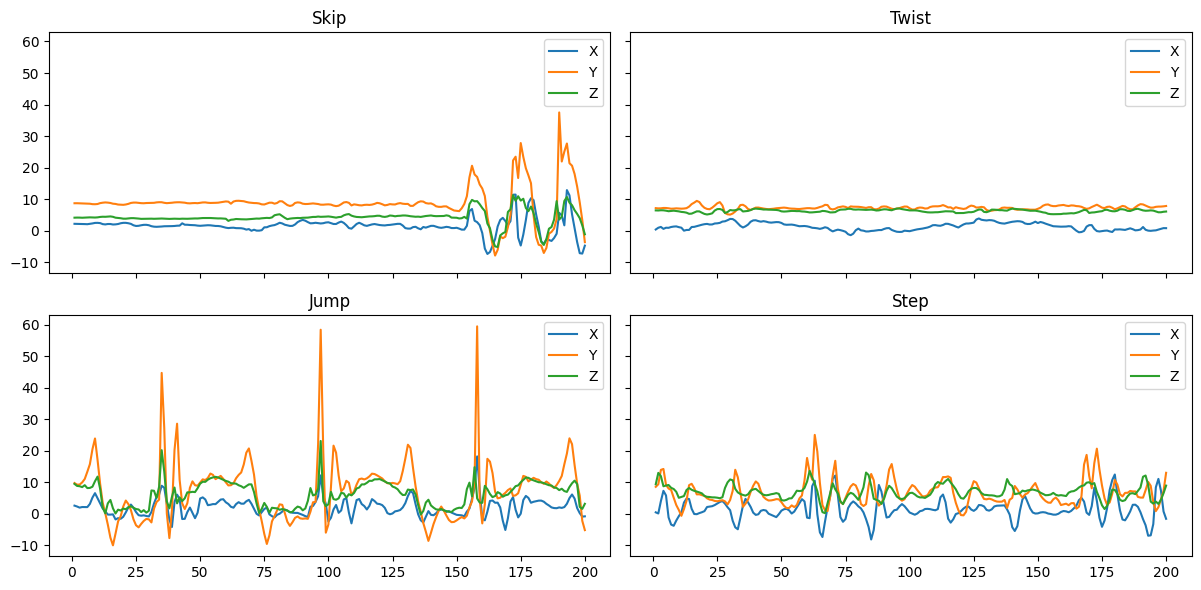

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

for ax, lbl in zip(axs.ravel(), labels.keys()):
    subset = data[data['META']['LABEL'] == lbl]
    if subset.empty:
        ax.set_title(f"{labels[lbl]} (sin muestras)")
        continue

    row = subset.iloc[2]
    ax.plot(row["X"], label="X")
    ax.plot(row["Y"], label="Y")
    ax.plot(row["Z"], label="Z")
    ax.set_title(labels[lbl])
    ax.legend()


plt.tight_layout()

Para un analisis más detallado, se ha creado este gráfico con plotly. Mediante un slider, se puede visualizar una muestra de cada clase (Skip, Twist, Jump, Step) y sus correspondientes datos de sensores. La función `make_plotly_graph` en `utils.py` se encarga de generar este gráfico interactivo (escrito en fichero aparte para mantener el notebook limpio).

In [7]:
from utils import make_plotly_graph

df_20 = data.groupby(data["META"]["LABEL"]).head(20)
make_plotly_graph(df_20, height=400, width=900)

Vamos ahora a calcular la energía de cada muestra, definida como la suma de las energías de cada eje. La energía de un eje se calcula como la suma de los cuadrados de sus valores a lo largo del tiempo. Esta métrica nos dará una idea de la intensidad general del movimiento registrado por el acelerómetro.

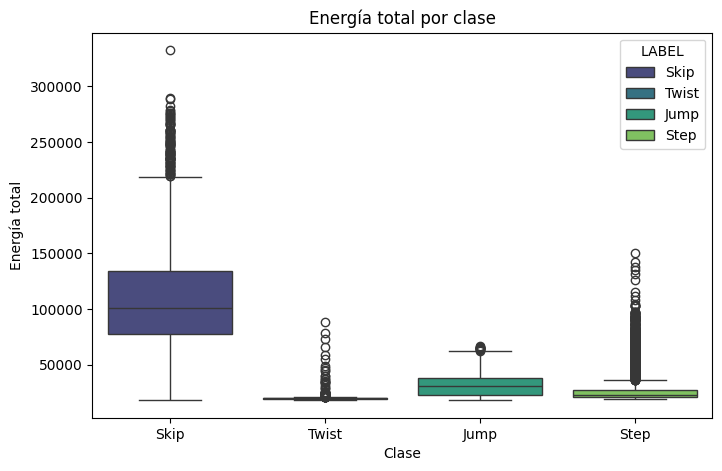

In [8]:
energia = (data["X"]**2 + data["Y"]**2 + data["Z"]**2).sum(axis=1)

plt.figure(figsize=(8, 5))
sns.boxplot(x=data["META"]["LABEL"], y=energia, palette="viridis", hue=data["META"]["LABEL"].map(labels))
plt.title("Energía total por clase")
plt.xlabel("Clase")
plt.ylabel("Energía total")
plt.xticks(ticks=[0, 1, 2, 3], labels=[labels[i] for i in sorted(labels.keys())])

plt.show()

Podemos ver como para todas las clases existe una gran cantidad de outliers. Este gráfico sugiere que la mayoría de los individuos realizarón los movimientos de manera relajada, pero hubo una cantidad significativa que se tomaron la grabación más en serio, realizando movimientos más intensos.

A continuación veremos la distribución de energía por usuario y clase:

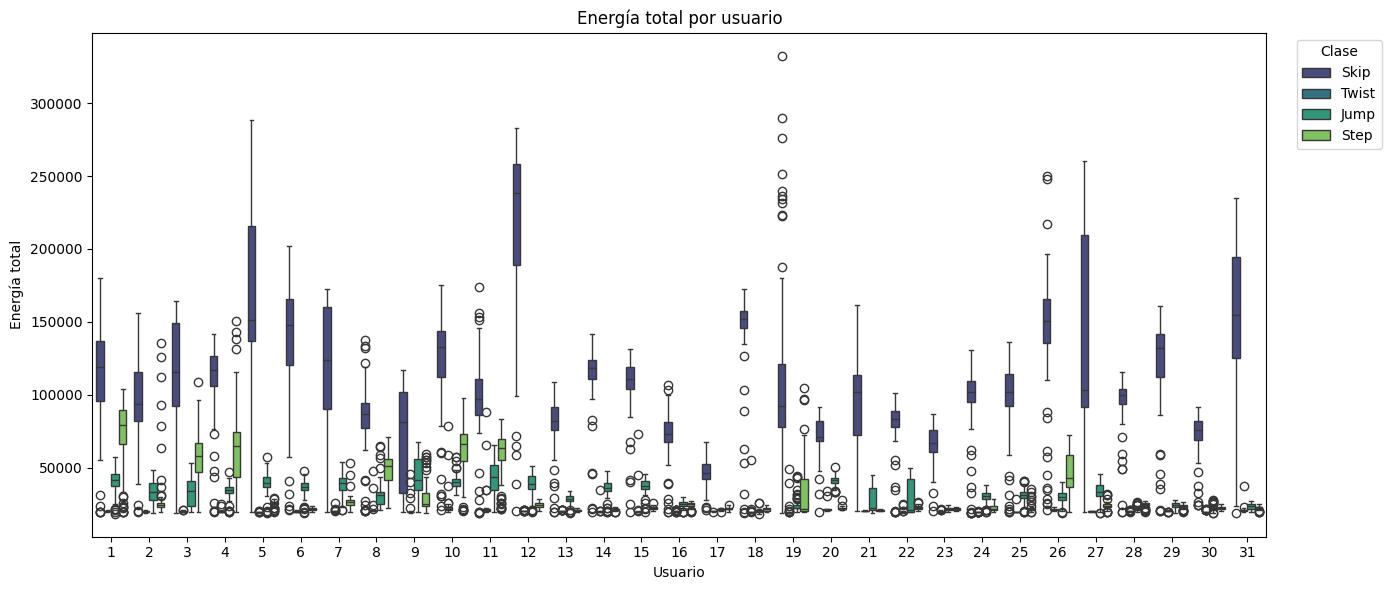

In [9]:
energia = (data["X"]**2 + data["Y"]**2 + data["Z"]**2).sum(axis=1)

plot_df = pd.DataFrame({
    "USER_ID": data["META"]["USER_ID"].astype(int),
    "LABEL": data["META"]["LABEL"].map(labels),  # Skip, Twist, Jump, Step
    "energia": energia
})

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="USER_ID", y="energia", hue="LABEL", palette="viridis")
plt.title("Energía total por usuario")
plt.xlabel("Usuario")
plt.ylabel("Energía total")
plt.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

Dados los datos, aplicaremos una transformación logarítmica a la energía. De otra forma dificilmente apreciaremos los detalles.

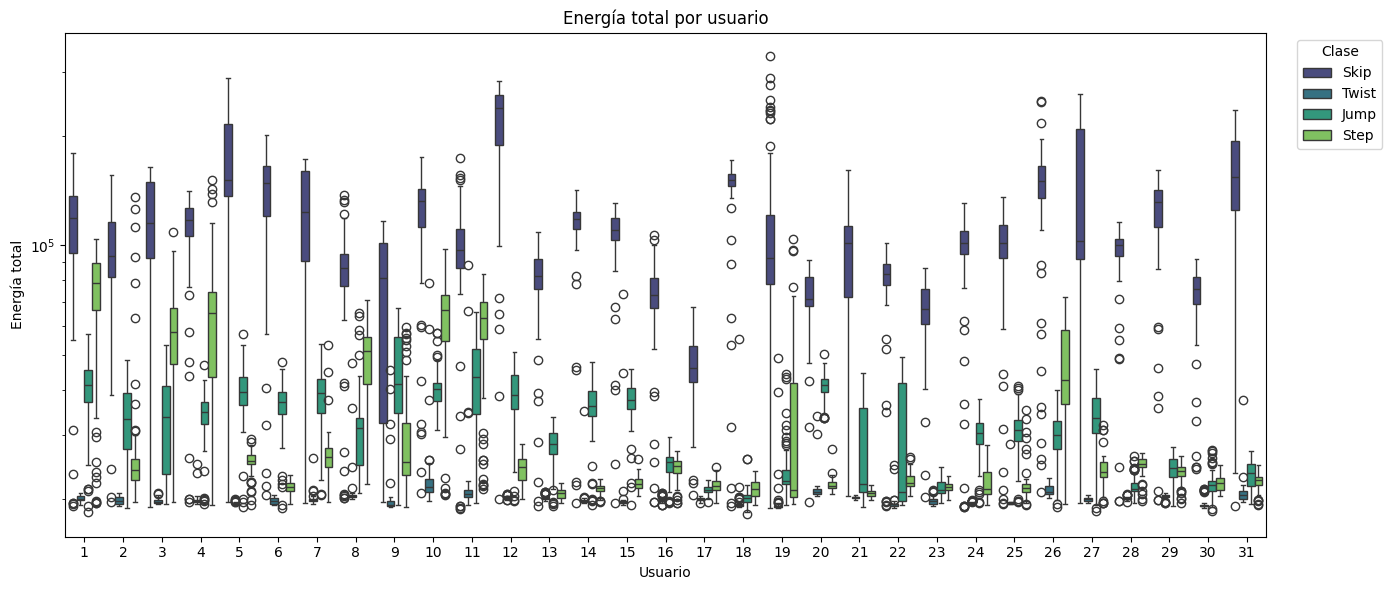

In [10]:
plot_df = pd.DataFrame({
    "USER_ID": data["META"]["USER_ID"].astype(int),
    "LABEL": data["META"]["LABEL"].map(labels),  # Skip, Twist, Jump, Step
    "energia": energia
})

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="USER_ID", y="energia", hue="LABEL", palette="viridis")
plt.title("Energía total por usuario")
plt.xlabel("Usuario")
plt.ylabel("Energía total")
plt.yscale("log")
plt.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Métricas avanzadas para caracterizar las señales
En esta sección ampliamos el EDA con métricas temporales, frecuenciales y de complejidad. El objetivo es identificar patrones que separen mejor las clases y, al mismo tiempo, evaluar cuánto influye el usuario en esas métricas.

En los apartados siguientes las métricas se organizan en **3 bloques**:
- **Bloque 1: temporal + periodicidad + dinámica** (`rms_mag`, `sma`, `zcr_mean`, `jerk_rms`). Resume intensidad total, ritmo de oscilación y brusquedad del movimiento.
- **Bloque 2: frecuencia** (`dominant_freq`, `spectral_centroid`, `bandpower_*`). Describe dónde se concentra la energía en el espectro.
- **Bloque 3: complejidad** (`spectral_entropy`, `autocorr_lag1`). Captura regularidad frente a variabilidad del patrón temporal.

In [11]:
# Preparacion de matrices base
X = data["X"].to_numpy()
Y = data["Y"].to_numpy()
Z = data["Z"].to_numpy()

_, n_steps = X.shape
fs = 50.0  # Hz
timestep = 1.0 / fs

mag = np.sqrt(X**2 + Y**2 + Z**2)
energia = (X**2 + Y**2 + Z**2).sum(axis=1)

def zcr_rows(arr):
    # Zero Crossing Rate por fila
    return (np.diff(np.signbit(arr), axis=1) != 0).sum(axis=1) / (arr.shape[1] - 1)

# Metricas temporales
rms_mag = np.sqrt(np.mean(mag**2, axis=1))
sma = (np.abs(X) + np.abs(Y) + np.abs(Z)).mean(axis=1)

zcr_x = zcr_rows(X)
zcr_y = zcr_rows(Y)
zcr_z = zcr_rows(Z)
zcr_mean = (zcr_x + zcr_y + zcr_z) / 3.0

# Jerk (derivada temporal de aceleracion)
dX = np.diff(X, axis=1) / timestep
dY = np.diff(Y, axis=1) / timestep
dZ = np.diff(Z, axis=1) / timestep
jerk_mag = np.sqrt(dX**2 + dY**2 + dZ**2)
jerk_rms = np.sqrt(np.mean(jerk_mag**2, axis=1))

# Espectral (sobre magnitud)
freqs = np.fft.rfftfreq(n_steps, d=timestep)
psd = np.abs(np.fft.rfft(mag, axis=1))**2
psd_sum = psd.sum(axis=1)

dominant_idx = np.argmax(psd[:, 1:], axis=1) + 1
dominant_freq = freqs[dominant_idx]
spectral_centroid = np.divide((psd * freqs).sum(axis=1), psd_sum, out=np.zeros_like(psd_sum), where=psd_sum > 0)

low_band = (freqs >= 0.0) & (freqs < 3.0)
mid_band = (freqs >= 3.0) & (freqs < 8.0)
high_band = (freqs >= 8.0) & (freqs <= 20.0)

bandpower_low = psd[:, low_band].sum(axis=1)
bandpower_mid = psd[:, mid_band].sum(axis=1)
bandpower_high = psd[:, high_band].sum(axis=1)

# Complejidad
p_spec = np.divide(psd, psd_sum[:, None], out=np.zeros_like(psd), where=psd_sum[:, None] > 0)
spectral_entropy = -(p_spec * np.log(p_spec + 1e-12)).sum(axis=1) / np.log(p_spec.shape[1])

mag_centered = mag - mag.mean(axis=1, keepdims=True)
ac_num = (mag_centered[:, :-1] * mag_centered[:, 1:]).sum(axis=1)
ac_den = (mag_centered**2).sum(axis=1)
autocorr_lag1 = np.divide(ac_num, ac_den, out=np.zeros_like(ac_num), where=ac_den > 0)

features_df = pd.DataFrame({
    "USER_ID": data["META"]["USER_ID"].astype(int),
    "LABEL_ID": data["META"]["LABEL"].astype(int),
    "LABEL": data["META"]["LABEL"].map(labels),
    "energia": energia,
    "rms_mag": rms_mag,
    "sma": sma,
    "zcr_mean": zcr_mean,
    "jerk_rms": jerk_rms,
    "dominant_freq": dominant_freq,
    "spectral_centroid": spectral_centroid,
    "bandpower_low": bandpower_low,
    "bandpower_mid": bandpower_mid,
    "bandpower_high": bandpower_high,
    "spectral_entropy": spectral_entropy,
    "autocorr_lag1": autocorr_lag1
})

features_df.head()

,USER_ID,LABEL_ID,LABEL,energia,rms_mag,sma,zcr_mean,jerk_rms,dominant_freq,spectral_centroid,bandpower_low,bandpower_mid,bandpower_high,spectral_entropy,autocorr_lag1
0,13,4,Step,19835.441994,9.958776,14.640699,0.020101,45.757853,2.75,0.047634,3.899643e+06,1.226262e+04,5.174777e+03,0.023675,0.845778
1,22,1,Skip,92748.565173,21.534689,22.609749,0.154104,877.150055,3.25,2.108408,9.923071e+06,2.811422e+06,1.335015e+06,0.321251,0.552772
2,1,1,Skip,166418.487708,28.846013,31.082145,0.189280,1027.064801,3.00,1.758388,2.002114e+07,4.167535e+06,2.385608e+06,0.241848,0.573407
3,19,2,Twist,18993.236461,9.745059,14.559207,0.000000,19.938103,6.75,0.003000,3.795416e+06,1.074543e+03,2.940214e+02,0.001267,0.647573
4,22,4,Step,21554.687695,10.381399,15.030826,0.040201,121.211357,2.75,0.146639,4.088322e+06,5.780107e+04,1.313826e+04,0.060423,0.821574


### 1) Métricas temporales y periodicidad
Analizamos estas métricas porque son las más directas para separar actividades por intensidad y cadencia:
- `rms_mag`: raíz cuadrática media de la magnitud. Resume intensidad global con más peso en picos.
- `sma`: media de `|X|+|Y|+|Z|`. Es robusta y muy utilizada en actividad humana.
- `zcr_mean`: tasa media de cruces por cero en ejes X/Y/Z. Captura ritmo; suele subir cuando el movimiento alterna dirección con frecuencia.
- `jerk_rms`: RMS de la derivada temporal de aceleración. Diferencia gestos suaves de gestos más abruptos.

Qué buscamos en los gráficos: separación de cajas/violines entre clases, solapamiento y variabilidad por usuario para detectar posible sesgo inter-sujeto.

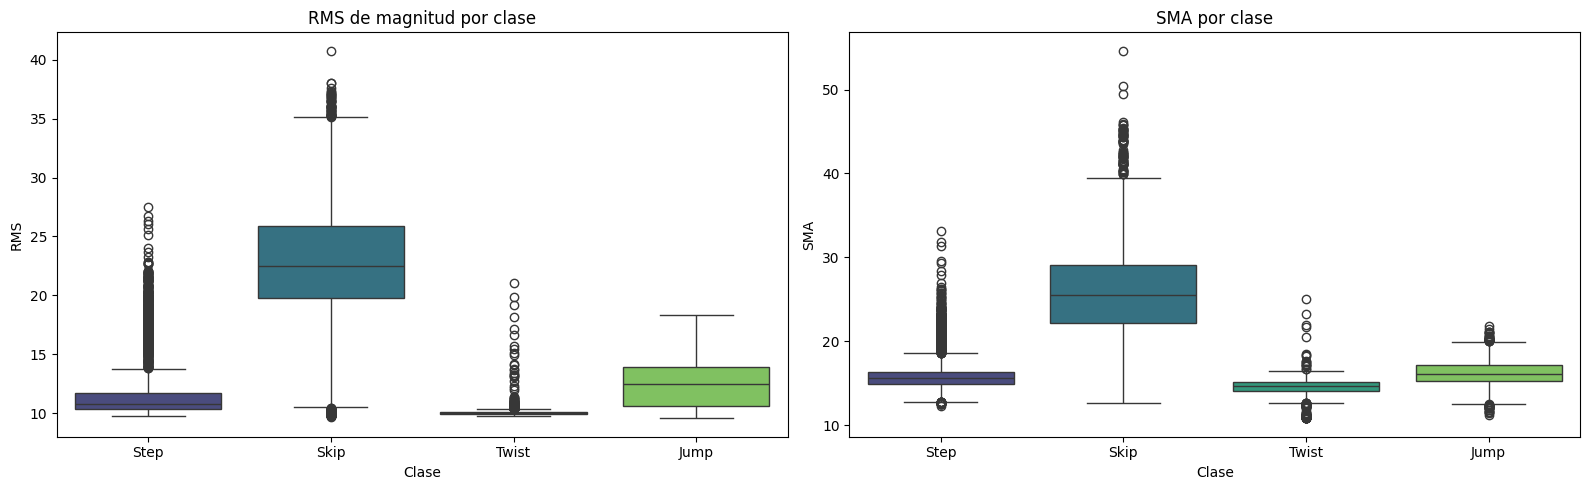

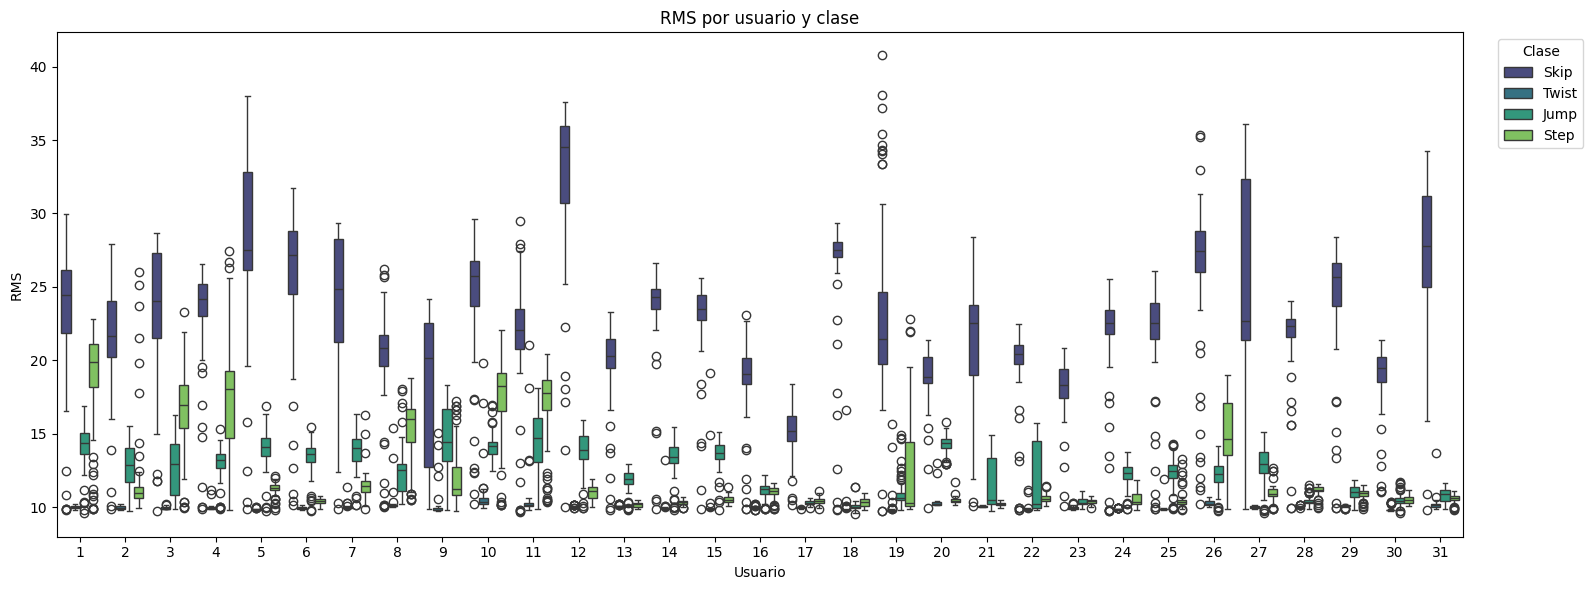

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=features_df, x="LABEL", y="rms_mag", ax=axes[0], palette="viridis", hue="LABEL")
axes[0].set_title("RMS de magnitud por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("RMS")
axes[0].legend([], [], frameon=False)

sns.boxplot(data=features_df, x="LABEL", y="sma", ax=axes[1], palette="viridis", hue="LABEL")
axes[1].set_title("SMA por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("SMA")
axes[1].legend([], [], frameon=False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(data=features_df, x="USER_ID", y="rms_mag", hue="LABEL", palette="viridis")
plt.title("RMS por usuario y clase")
plt.xlabel("Usuario")
plt.ylabel("RMS")
plt.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

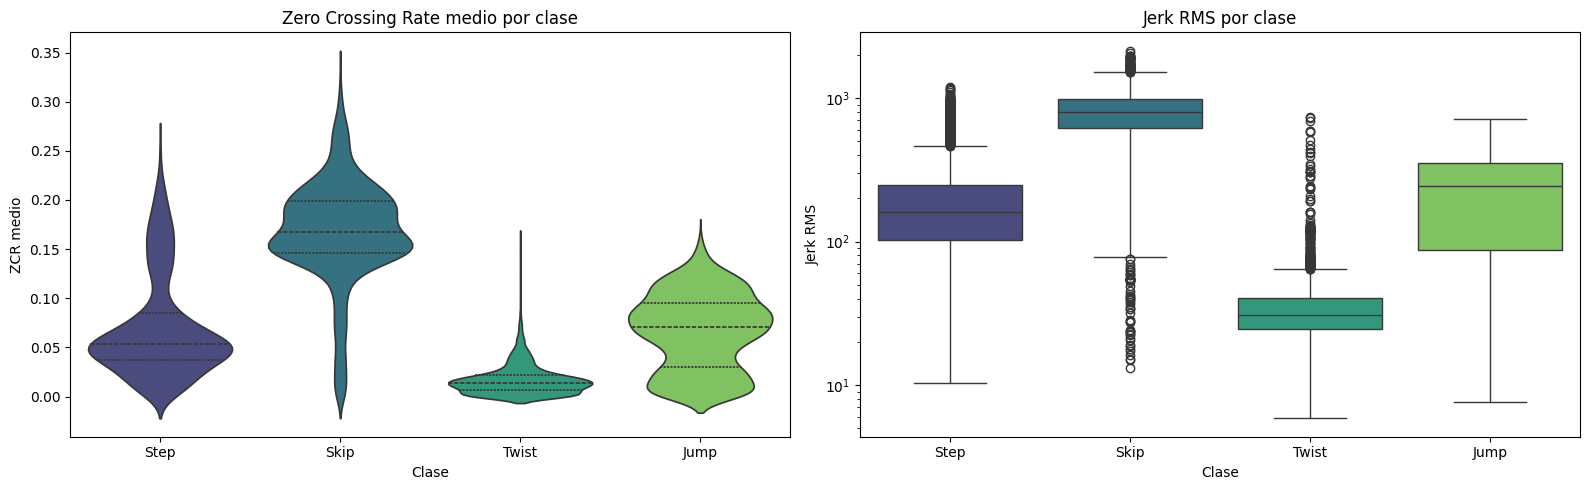

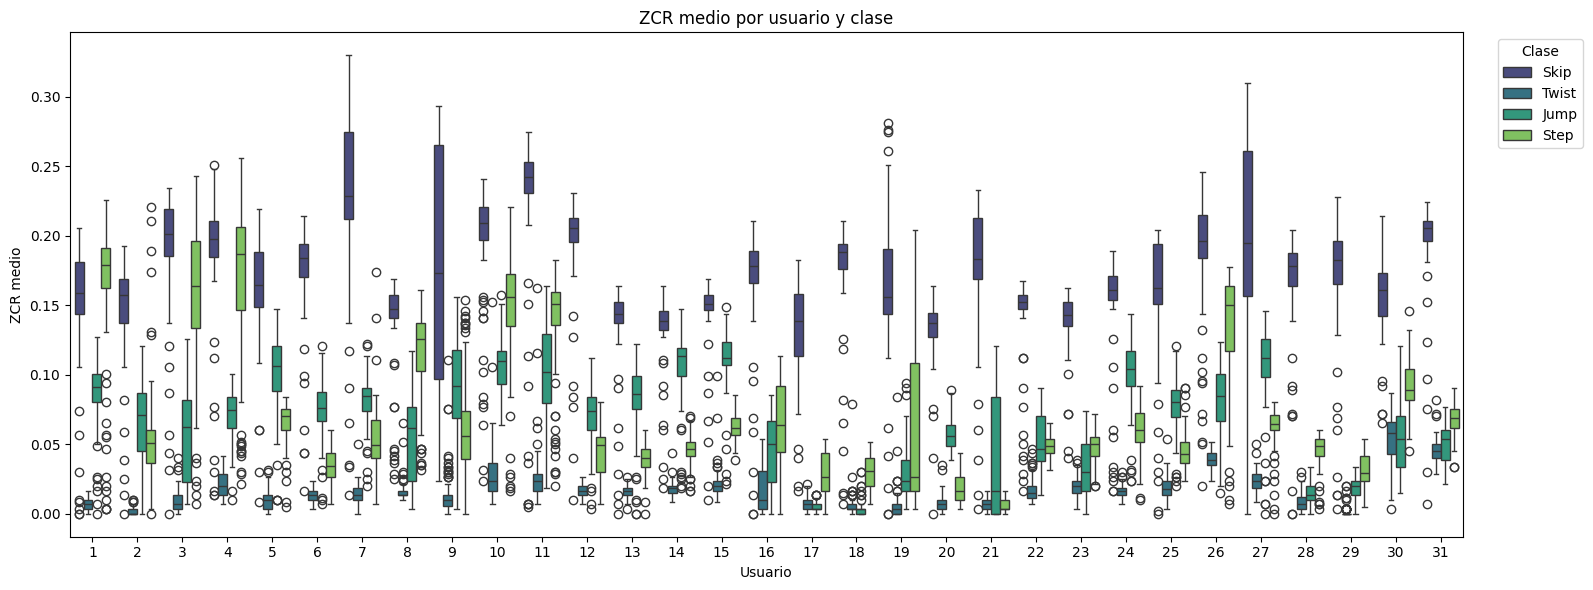

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(data=features_df, x="LABEL", y="zcr_mean", ax=axes[0], palette="viridis", hue="LABEL", inner="quart")
axes[0].set_title("Zero Crossing Rate medio por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("ZCR medio")
axes[0].legend([], [], frameon=False)

sns.boxplot(data=features_df, x="LABEL", y="jerk_rms", ax=axes[1], palette="viridis", hue="LABEL")
axes[1].set_title("Jerk RMS por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Jerk RMS")
axes[1].set_yscale("log")
axes[1].legend([], [], frameon=False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(data=features_df, x="USER_ID", y="zcr_mean", hue="LABEL", palette="viridis")
plt.title("ZCR medio por usuario y clase")
plt.xlabel("Usuario")
plt.ylabel("ZCR medio")
plt.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 2) Análisis en frecuencia
Extraemos frecuencia dominante, centroide espectral y potencia en bandas para capturar el ritmo de cada actividad.

**PSD** (*Power Spectral Density*): resume cuánta energía hay en cada frecuencia y sirve como base para `dominant_freq`, `spectral_centroid` y `bandpower_*`.

Por qué estas métricas:
- `dominant_freq`: frecuencia de mayor potencia. Identifica la cadencia principal del gesto.
- `spectral_centroid`: centro de masa del espectro. Indica si la energía está desplazada a frecuencias bajas o altas.
- `bandpower_low/mid/high`: energía acumulada por banda. Facilita comparar perfiles espectrales entre clases.

Qué buscamos: clases con picos de frecuencia distintos y repartos de energía diferentes por bandas, porque eso sugiere patrones motores específicos.

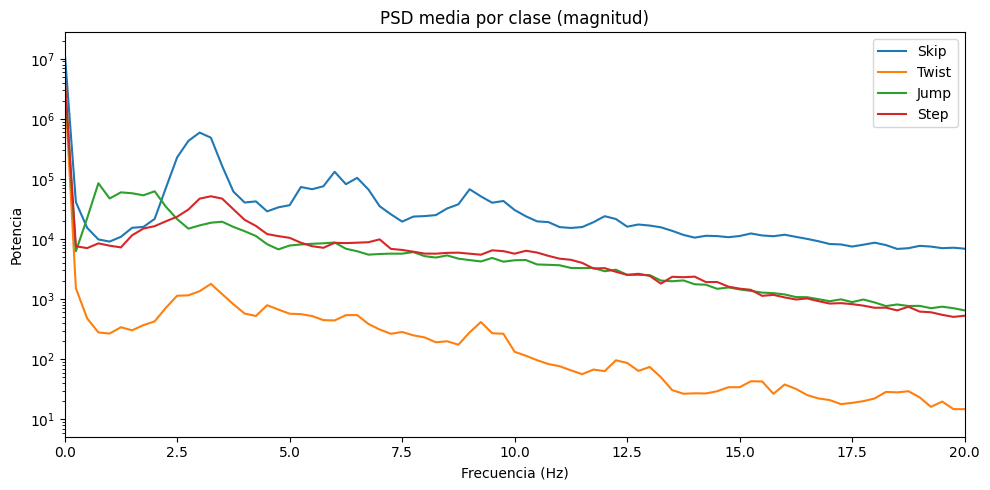

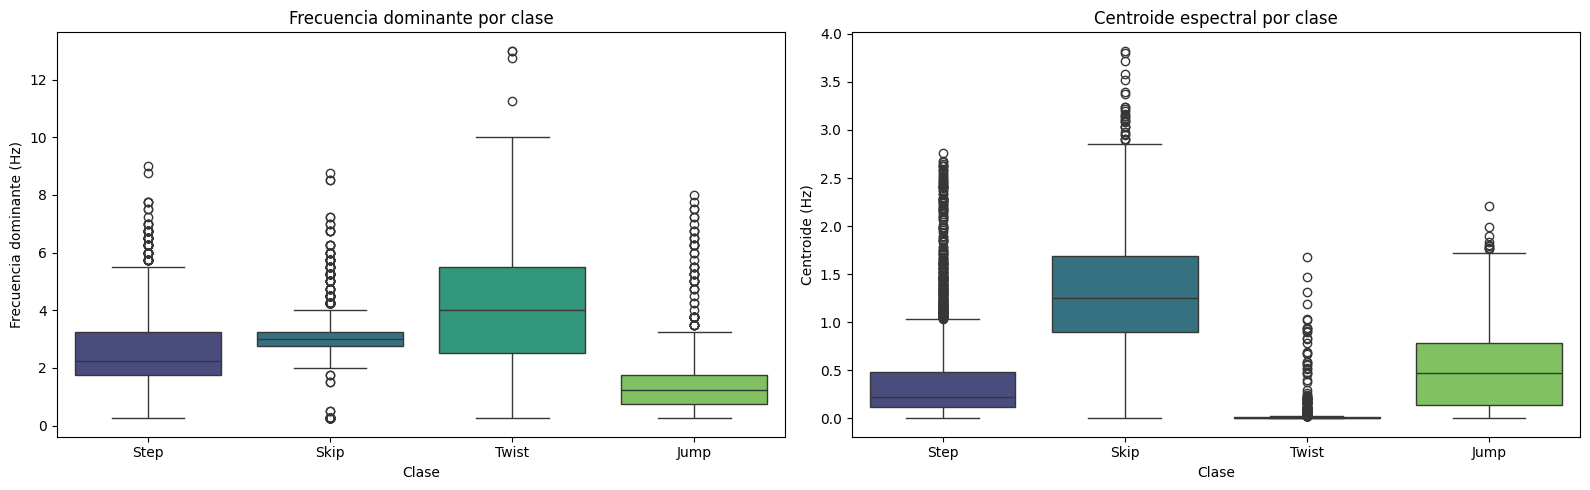

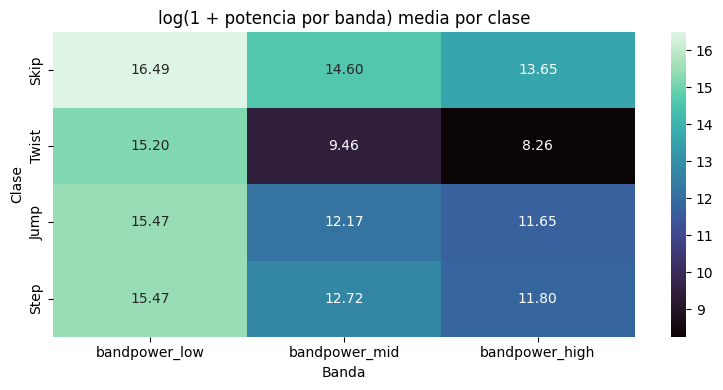

In [14]:
mean_psd_by_label = {}
for class_id, class_name in labels.items():
    class_mask = (features_df["LABEL_ID"].to_numpy() == class_id)
    mean_psd_by_label[class_name] = psd[class_mask].mean(axis=0)

plt.figure(figsize=(10, 5))
for class_name in [labels[i] for i in sorted(labels.keys())]:
    plt.plot(freqs, mean_psd_by_label[class_name], label=class_name)
plt.title("PSD media por clase (magnitud)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia")
plt.yscale("log")
plt.xlim(0, 20)
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=features_df, x="LABEL", y="dominant_freq", ax=axes[0], palette="viridis", hue="LABEL")
axes[0].set_title("Frecuencia dominante por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Frecuencia dominante (Hz)")
axes[0].legend([], [], frameon=False)

sns.boxplot(data=features_df, x="LABEL", y="spectral_centroid", ax=axes[1], palette="viridis", hue="LABEL")
axes[1].set_title("Centroide espectral por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Centroide (Hz)")
axes[1].legend([], [], frameon=False)

plt.tight_layout()
plt.show()

band_df = (
    features_df.groupby("LABEL")[["bandpower_low", "bandpower_mid", "bandpower_high"]]
    .mean()
    .reindex([labels[i] for i in sorted(labels.keys())])
)

plt.figure(figsize=(8, 4))
sns.heatmap(np.log1p(band_df), annot=True, fmt=".2f", cmap="mako")
plt.title("log(1 + potencia por banda) media por clase")
plt.xlabel("Banda")
plt.ylabel("Clase")
plt.tight_layout()
plt.show()

### 3) Complejidad de señal
Usamos entropía espectral y autocorrelación para cuantificar regularidad temporal.

Interpretación:
- `spectral_entropy`: mide cuán distribuida está la potencia en frecuencias. Valores altos implican señales más complejas/irregulares.
- `autocorr_lag1`: mide cuánto se parece la señal a sí misma con un pequeño desfase. Valores altos suelen indicar mayor regularidad.

Por qué analizarlo: dos actividades pueden tener intensidad parecida pero estructura temporal diferente; estas métricas ayudan a distinguir esos casos.

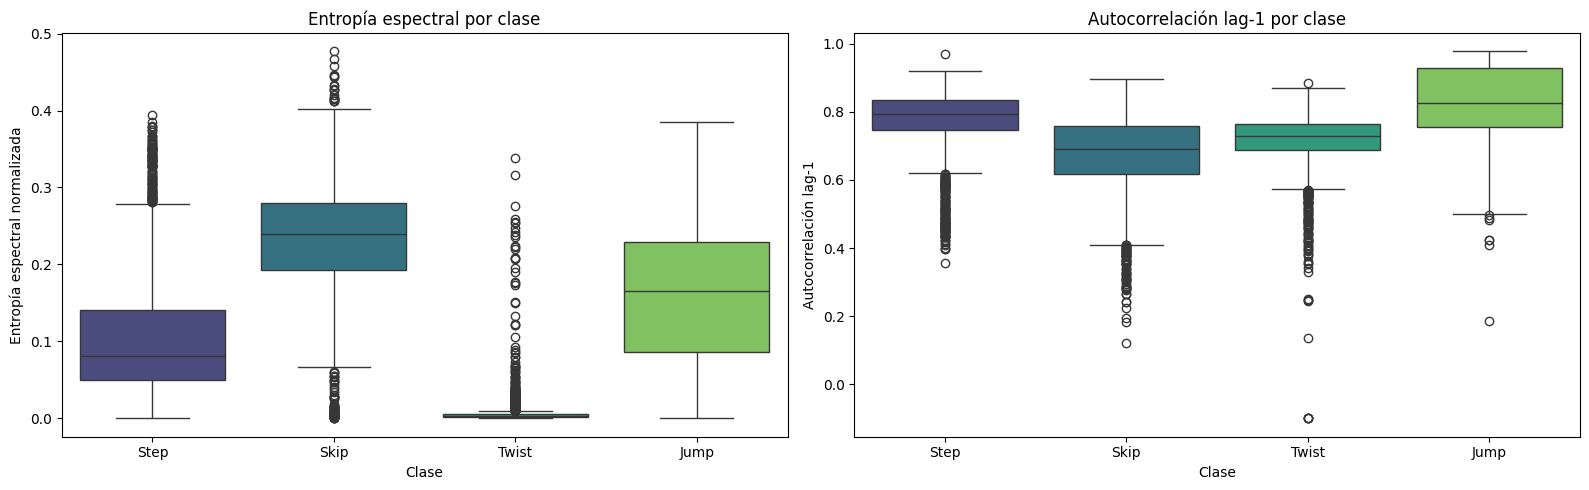

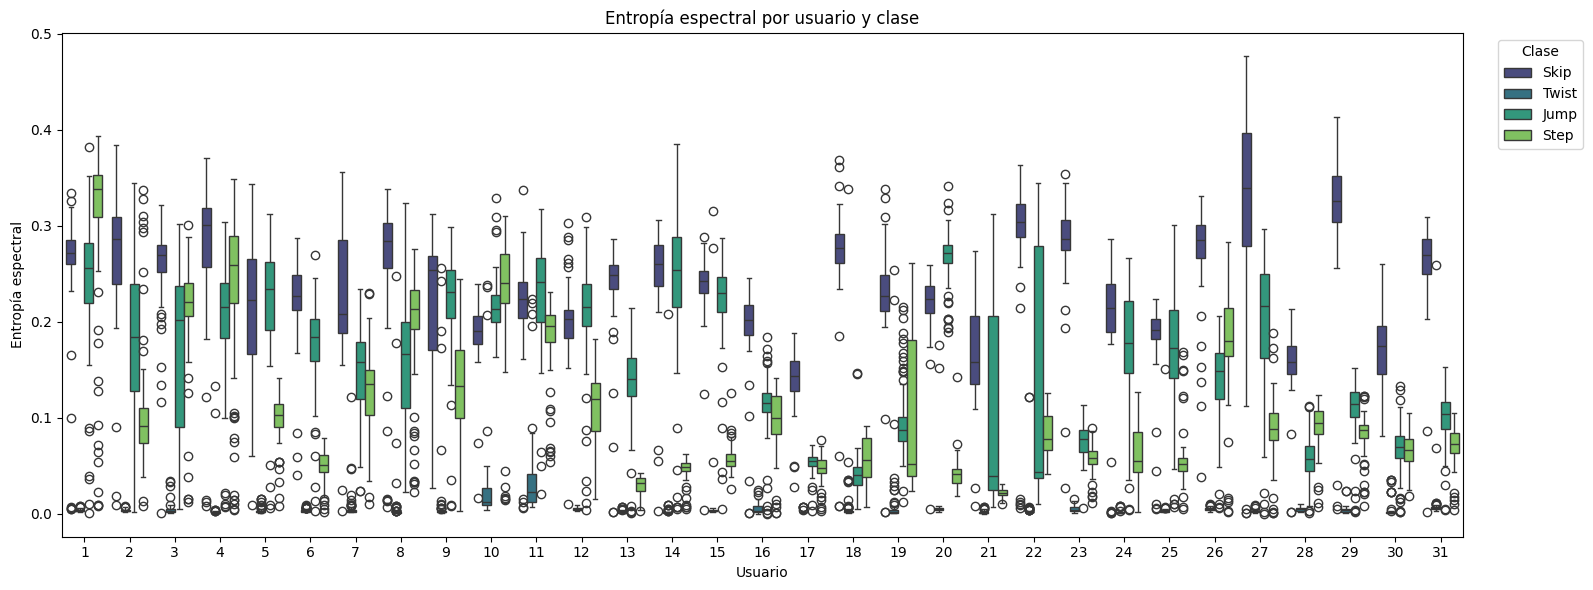

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=features_df, x="LABEL", y="spectral_entropy", ax=axes[0], palette="viridis", hue="LABEL")
axes[0].set_title("Entropía espectral por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Entropía espectral normalizada")
axes[0].legend([], [], frameon=False)

sns.boxplot(data=features_df, x="LABEL", y="autocorr_lag1", ax=axes[1], palette="viridis", hue="LABEL")
axes[1].set_title("Autocorrelación lag-1 por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Autocorrelación lag-1")
axes[1].legend([], [], frameon=False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(data=features_df, x="USER_ID", y="spectral_entropy", hue="LABEL", palette="viridis")
plt.title("Entropía espectral por usuario y clase")
plt.xlabel("Usuario")
plt.ylabel("Entropía espectral")
plt.legend(title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 4) Proyección no lineal con t-SNE y evaluación de agrupamiento
Añadimos t-SNE para visualizar si las clases forman grupos en un espacio 2D no lineal. La evaluación cuantitativa de agrupamiento se hace en el espacio de *features escaladas* (no sobre el embedding de t-SNE).

Cómo interpretar ARI:
- Cercano a 1: el agrupamiento no supervisado coincide bien con las clases.
- Cercano a 0: parecido a asignación aleatoria.
- Negativo: peor que aleatorio.

También reportamos NMI (información mutua normalizada) y silhouette como métricas complementarias.

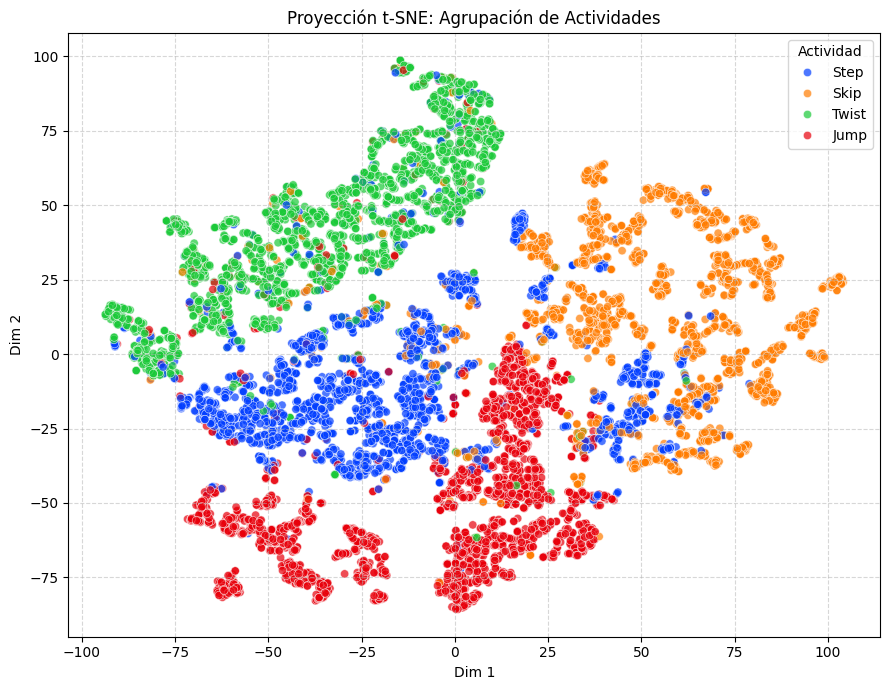

,Espacio,ARI,NMI,Silhouette
0,Features escaladas,0.3091,0.3931,0.3691


In [16]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler

tsne_features = [
    "energia",
    "rms_mag",
    "sma",
    "zcr_mean",
    "jerk_rms",
    "dominant_freq",
    "spectral_centroid",
    "bandpower_low",
    "bandpower_mid",
    "bandpower_high",
    "spectral_entropy",
    "autocorr_lag1",
]

features_num = features_df[tsne_features].to_numpy()
y_true = features_df["LABEL_ID"].to_numpy()

scaler_eda = StandardScaler()
X_scaled_eda = scaler_eda.fit_transform(features_num)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
    )
X_tsne = tsne.fit_transform(X_scaled_eda)

df_tsne = pd.DataFrame(X_tsne, columns=["Dim 1", "Dim 2"])
df_tsne["Actividad"] = features_df["LABEL"].to_numpy()

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_tsne,
    x="Dim 1",
    y="Dim 2",
    hue="Actividad",
    palette="bright",
    alpha=0.7
    )
plt.title("Proyección t-SNE: Agrupación de Actividades")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

n_clusters = len(labels)
kmeans_scaled = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled_eda)

metrics_df = pd.DataFrame(
    [
        {
            "Espacio": "Features escaladas",
            "ARI": adjusted_rand_score(y_true, clusters_scaled),
            "NMI": normalized_mutual_info_score(y_true, clusters_scaled),
            "Silhouette": silhouette_score(X_scaled_eda, clusters_scaled),
        }
    ]
).round(4)

metrics_df

### Conclusión del agrupamiento
Los resultados indican que las métricas extraídas tienen una capacidad **moderada** para agrupar las muestras por clase en el espacio de features escaladas. Un `ARI` de 0.3091 y un `NMI` de 0.3931 muestran que existe estructura de clase, pero no una separación limpia; es decir, las actividades comparten bastante solapamiento y no forman grupos totalmente puros. El `Silhouette` de 0.3691 refuerza esta lectura: el agrupamiento es mejor que aleatorio, pero todavía hay mezcla entre clases.

En la práctica, esto sugiere que las métricas capturan información útil, pero no suficiente por sí solas para separar perfectamente las actividades. Por eso tiene sentido combinarlas con modelos supervisados y validación por sujeto, donde el patrón completo de la señal puede explotarse mejor.